# CMFV Controllers
With my initial sim, exploring how I can control better

## Previous sim code:

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from dataclasses import dataclass

DEG_TO_RAD = np.pi/180
RAD_TO_DEG = 180/np.pi

In [102]:
# Modules

class PressureTransducer:
    def __init__(self, sigma_p: float, p0 = 0):
        self.sigma_p = sigma_p
        self.p_hat = p0

    def observe(self, p):
        """Adds noise to pressure and returns"""
        self.p_hat = np.random.normal(p, self.sigma_p)
        return self.p_hat

class ValveAngle:
    def __init__(self, dt: float, theta0 = 0.0, sigma = 0, bounds = (0,90)):
        self.dt = dt
        self.theta = theta0
        self.sigma = sigma
        self.bounds = bounds

    def step(self, theta_dot: float):
        """Integrates then adds noise"""
        self.theta = self.theta + self.dt * theta_dot
        self.theta = np.random.normal(self.theta, self.sigma) # Maybe not add this?
        return np.clip(self.theta, *self.bounds)

# ASSUMPTION: incompressible / no density change
# ASSUMPTION: no diameter change
MAX_ANGLE_DEG = 90
class Valve:
    def __init__(self, rho = 1.0, A = 1.0):
        self.rho = rho
        self.A = A
        

    def across(self, p1: float, v1: float, theta_deg: float):
        """(p1, v1) --> p2 TODO: fix"""
        E1 = p1 + 0.5*self.rho*v1*v1
        
        # E_loss = (theta_deg/90)*E1 # Make this better but it's linear for now

        # Function I threw together from the last cell
        E_loss = -(np.cos((theta_deg/MAX_ANGLE_DEG*np.pi)) - 1) / 2 * E1 

        E2 = E1 - E_loss

        # Must be traveling at same speed since pipe is same A_cs
        v2 = v1
        p2 = E2 - 0.5*self.rho*v2*v2

        return p2

class Controller:
    def __init__(self):
        pass

    def control(self, p_ref: float, p_meas: float):
        pass

In [103]:
# Structs

@dataclass
class CmfvSimOutputs:
    time: np.ndarray
    
    # Truth
    theta: np.ndarray
    p_truth: np.ndarray

    # Command
    theta_dot_cmd: np.ndarray
    p_setpoint: np.ndarray

    # Observation
    p_meas: np.ndarray

@dataclass 
class CmfvSimInputs:
    # Sim
    dt: float
    nsteps: int

    # 

    # Noise
    sigma_angle: float
    sigma_p: float



    seed: int | None = 273

@dataclass 
class CmfvSimInitialConditions:
    p_tank: float # Pa
    v: float # m/s
    theta: float

In [104]:
# Running and plotting

def run_sim(sim_in: CmfvSimInputs, ICs: CmfvSimInitialConditions, controller: Controller, p_r_func: Callable[[float], float]) -> CmfvSimOutputs:
    
    if sim_in.seed is not None:
        np.random.seed(sim_in.seed) 

    angle_integrator = ValveAngle(sim_in.dt, ICs.theta, sim_in.sigma_angle)
    valve = Valve(rho=1, A=1)
    
    p_out0 = valve.across(ICs.p_tank, ICs.v, ICs.theta) # Initial pressure on other side
    ducer = PressureTransducer(sim_in.sigma_p, p_out0)

    N = sim_in.nsteps
    dt = sim_in.dt

    ts = np.arange(N+1)*dt

    angles = np.zeros((N+1))
    p_truth = np.zeros((N+1))
    p_meas = np.zeros((N+1))
    p_setpoints = np.zeros((N+1))
    theta_dots = np.zeros((N+1))

    angles[0] = ICs.theta
    p_truth[0] = p_out0

    p_meas[0] = ducer.observe(p_truth[0])
    p_setpoints[0] = p_r_func(ts[0])
    theta_dots[0] = controller.control(p_setpoints[0], p_meas[0])

    for i in range(N):

        # Advance angle according to command
        angle = angle_integrator.step(theta_dots[i])
        
        # Just having velocity equal to starting one 
        v = ICs.v
        p_downstream = valve.across(ICs.p_tank, v, angle)

        angles[i+1] = angle
        p_truth[i+1] = p_downstream
        p_meas[i+1] = ducer.observe(p_downstream)

        # Get setpoint for the current step
        p_setpoints[i+1] = p_r_func(ts[i])
        theta_dots[i+1] = controller.control(p_setpoints[i+1], p_meas[i+1])

    return CmfvSimOutputs(
        time = ts,
        theta = angles,
        p_truth = p_truth,
        theta_dot_cmd = theta_dots,
        p_meas = p_meas,
        p_setpoint = p_setpoints
    )
    
def plot_sim(out: CmfvSimOutputs, start = 0, stop = -1, figsize = (12,8)):
    
    # Plot for pressure vs. setpoint
    plt.figure(figsize=figsize)
    # plt.
    # plt.subplot(3, 1, 1)
    plt.title("Pressure vs. Setpoint")
    plt.plot(out.time[start:stop], out.p_setpoint[start:stop], label="Setpoint", linestyle="-.", color="r")
    plt.plot(out.time[start:stop], out.p_meas[start:stop], label="Measured pressure", color="tab:orange")
    plt.plot(out.time[start:stop], out.p_truth[start:stop], label="Pressure", color="tab:blue")
    plt.legend()
    plt.xlabel("Time [s]")
    plt.ylabel("Pressure [Pa]")
    plt.show()

    # Plot for angle vs. time
    plt.figure(figsize=figsize)
    plt.title("Valve angle")
    plt.plot(out.time[start:stop], out.theta[start:stop], label="Valve Angle")
    plt.xlabel("Time [s]")
    plt.ylabel("Angle [deg]")
    plt.show()

    # Plot for angle_dot vs. time
    plt.figure(figsize=figsize)
    plt.title("Valve angle command")
    plt.plot(out.time[start:stop], out.theta_dot_cmd[start:stop], label="Angle command")
    plt.xlabel("Time [s]")
    plt.ylabel("Command [deg/s]")
    plt.show()


## Controllers

In [105]:
# Kp has units of (deg/s)/Pa because of transfer function
class PDController(Controller):
    def __init__(self, Kp: float, Kd: float, dt: float):
        self.Kp = Kp
        self.Kd = Kd
        self.dt = dt
        self.err_prev = None
        

    def control(self, p_ref: float, p_meas: float):
        err = p_ref - p_meas

        if self.err_prev is None:
            self.err_prev = err
            de = 0
        else:
            de = (err - self.err_prev) / self.dt
            self.err_prev = err


        P_term = self.Kp * err
        D_term = self.Kd * de
        # print(de)
        # print(P_term)
        # print(D_term)
        return -np.clip(P_term + D_term, -40, 40) # deg /s
    
class PController(Controller):
    def __init__(self, Kp: float):
        self.Kp = Kp

    def control(self, p_ref: float, p_meas: float):
        command = self.Kp * (p_ref - p_meas)
        return -np.clip(command, -40, 40) # deg /s

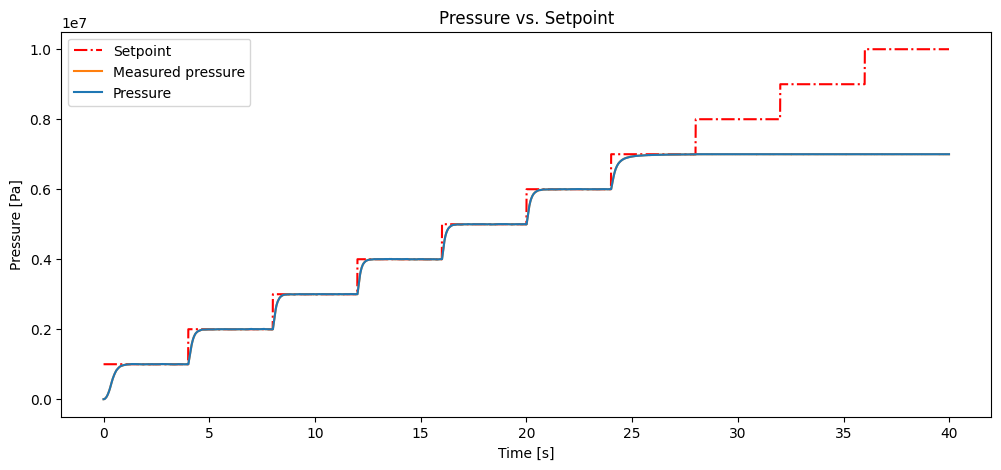

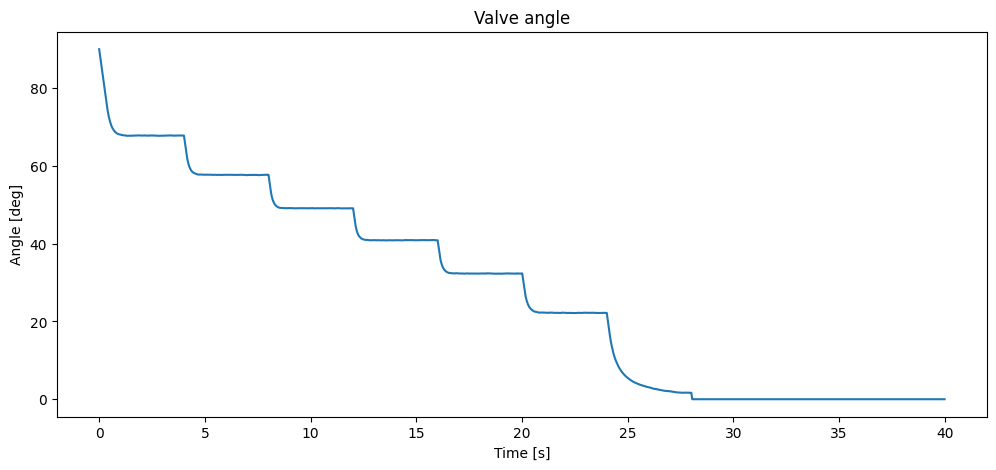

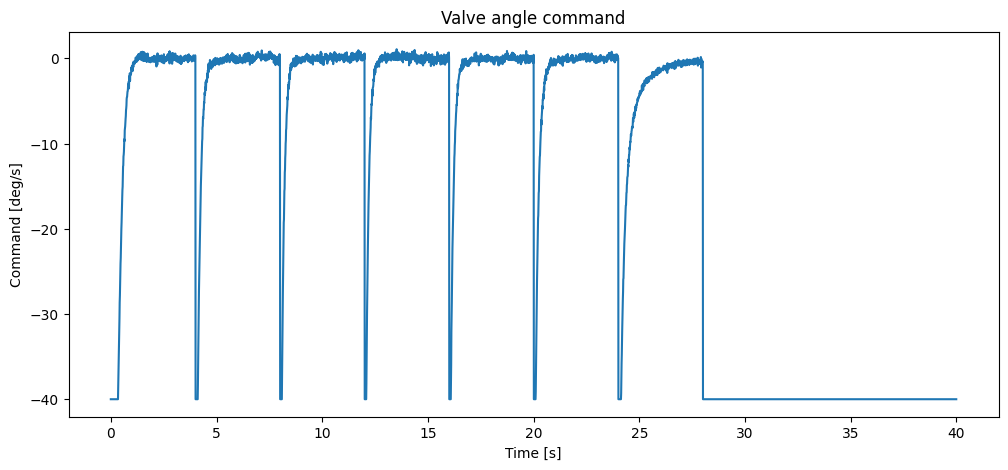

In [106]:
sim_in = CmfvSimInputs(
    dt = 0.01,
    nsteps = 4000,
    sigma_angle = 0.01, # deg/s
    sigma_p = 1000, # Pa
    # seed = 173
)

sim_ICs = CmfvSimInitialConditions(
    p_tank = 7e6, # Pa
    v = 1, # m/s
    theta = 90
)

def setpoint(t):
    return np.floor(t/4) * 1e6 + 1e6


# Iterating on these for it to work with the ramp
Kp = 0.00007
# Kp = 0
Kd = .000001
# Kd = 0
controller = PDController(Kp, Kd, sim_in.dt)
# controller = PController(Kp)

sim_out = run_sim(sim_in, sim_ICs, controller, setpoint)

start = 0
stop = -1

plot_sim(sim_out, start=start, stop=stop, figsize=(12,5))

In [107]:
class PIController(Controller):
    def __init__(self, Kp: float, Ki: float, dt: float, windup_tolerance: float):
        self.Kp = Kp
        self.Ki = Ki
        self.dt = dt
        self.tol = windup_tolerance

        self.integraded_err = 0

    def control(self, p_ref: float, p_meas: float):
        err = p_ref - p_meas

        if abs(self.integraded_err) < self.tol:
            self.integraded_err += self.dt*err


        P_term = self.Kp * err
        I_term = self.Ki * self.integraded_err
        # print(de)
        # print(P_term)
        # print(D_term)
        return -np.clip(P_term + I_term, -40, 40) # deg /s

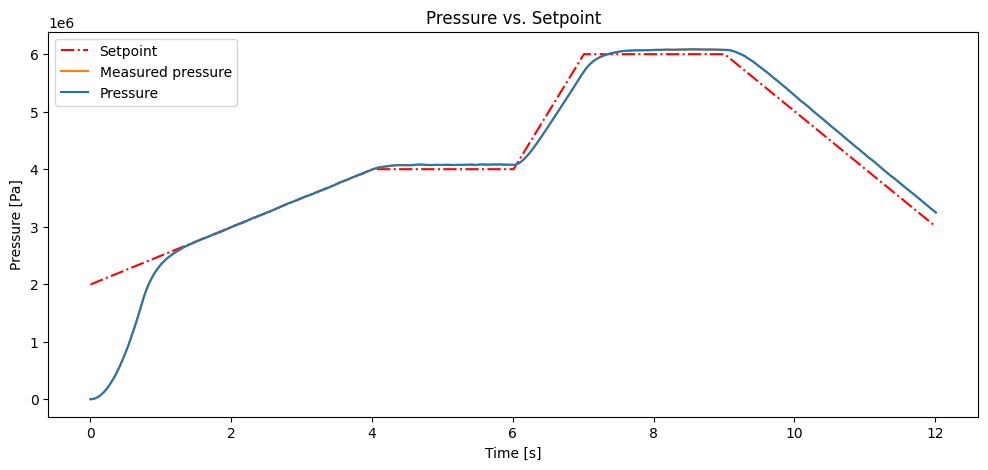

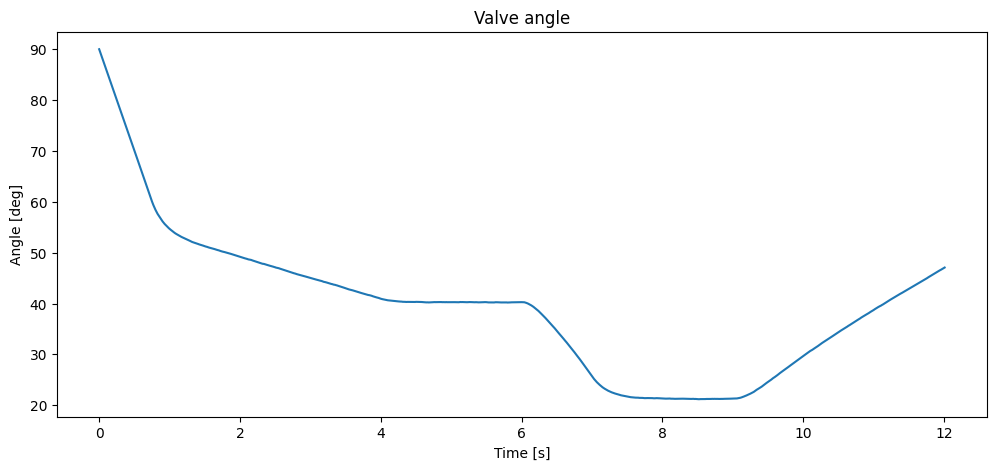

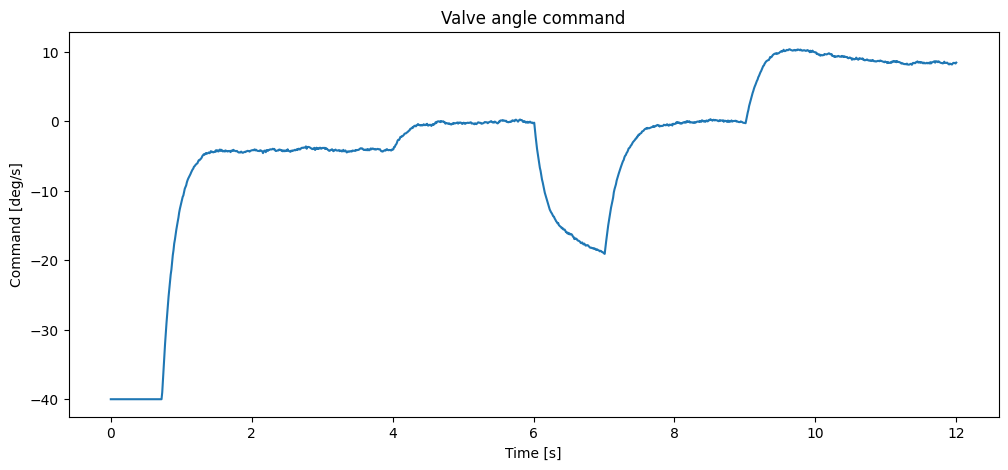

In [110]:
# This is where we need to turn to different types of controllers
def rampish(t):
    """(0, 3e6)--> (4, 4e6) then (6, 4e6)--> (7, 6e6) then (9, 6e6)--> (12, 3e6) then 3e6"""
    if t < 4:
        return 2e6*t/4 + 2e6
    elif t < 6:
        return 4e6
    elif t < 7:
        return 2e6*(t-6) + 4e6
    elif t < 9:
        return 6e6
    elif t < 12:
        return -1e6*(t-9) + 6e6

Kp = 0.00005
Ki = 0.000004
controller = PIController(Kp, Ki, sim_in.dt, 1000000)

sim_out = run_sim(sim_in, sim_ICs, controller, rampish)

start = 0
stop = -1

plot_sim(sim_out, start=start, stop=stop, figsize=(12,5))